# WEEK 8 SVM journal

In this notebook I am testing Support Vector Machines on the RAVDESS audio features.

The assignment directions say the MiniLearn SVM is a simplified linear SVM, so I use my from-scratch linear SVM on a binary emotion problem first. Then I use sklearn's SVC for the full multiclass emotion problem with linear, RBF, and polynomial kernels.


In [35]:
# Week 8: SVM Classification for Speech Emotion Recognition
# Comparing MiniLearn SVM vs scikit-learn SVM with different kernels

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score as sk_f1,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)


if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())

from minilearn.helper import ezcols
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.preprocessing.test_train_splitfunc import train_test_split




Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


Loading up the feature dataset below

In [36]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


Down below I am picking the actual feature columns and the emotion column/target. Since this is a simple linear I am going to split it up into two different emotions to go up against. The most sane sounding is probably happy and sad

In [37]:
feature_cols = ezcols()

twoemotions =  features[features["emotion"].isin(["happy", "sad"])].copy()



X = twoemotions[feature_cols]
y = twoemotions["emotion"]

print(X.shape)
print(y.value_counts())

(752, 480)
emotion
happy    376
sad      376
Name: count, dtype: int64


My algorithm was not as good as the one used with SKLEARN. it has a higher train accuracy and test accuracy. However I am a little worried by the 100% train accuracy out of the SKLEAN model which means there probably was some type of over fitting.

In [38]:
from sklearn.svm import SVC
from minilearn.classifiers.SVM import SVMMM
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

skimodel_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)
minilearnmodel_linear = SVMMM(C=1.0, learning=0.001, max_iters=1000)

skimodel_linear.fit(X_train_scaled, y_train)
minilearnmodel_linear.fit(X_train_scaled, y_train)

ski_pred = skimodel_linear.predict(X_test_scaled)
mini_pred = minilearnmodel_linear.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodel_linear.score(X_train_scaled, y_train))
print("MiniLearn test accuracy:", minilearnmodel_linear.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodel_linear.score(X_train_scaled, y_train))
print("Sklearn test accuracy:", skimodel_linear.score(X_test_scaled, y_test))

(602, 480)
(150, 480)
MiniLearn train accuracy: 0.9169435215946844
MiniLearn test accuracy: 0.82
Sklearn train accuracy: 1.0
Sklearn test accuracy: 0.88


Sklearn linear SVM
Accuracy: 0.88
Precision macro: 0.8773619186046512
Recall macro: 0.8773619186046512
F1 macro: 0.8773619186046512
F1 weighted: 0.88


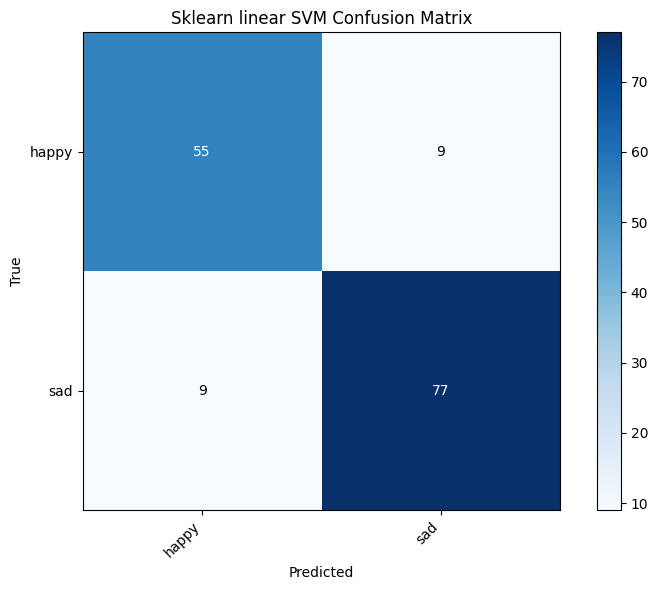

MiniLearn linear SVM
Accuracy: 0.82
Precision macro: 0.8221846646504181
Recall macro: 0.8290334302325582
F1 macro: 0.8193496587715777
F1 weighted: 0.8209393817743879


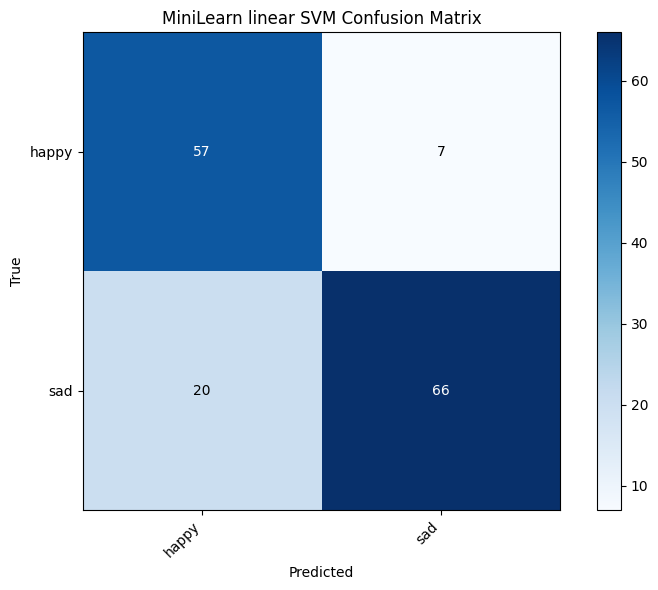

In [39]:
from minilearn.metrics.metricss import (
    accuracy,
    confusion_matrix,
    precision,
    recall,
    f1_score,
    roc_auc,
    plot_confusion_matrix,
)

classes = y.unique()

classes = y.unique()
labels = classes.tolist()    # ← convert numpy array to Python list
class_names = labels

ski_pred = skimodel_linear.predict(X_test_scaled)
mini_pred = minilearnmodel_linear.predict(X_test_scaled)

for model_name, preds in [
    ("Sklearn linear SVM", ski_pred),
    ("MiniLearn linear SVM", mini_pred)
]:
    print("=" * 50)
    print(model_name)
    print("Accuracy:", accuracy(y_test, preds))
    print("Precision macro:", precision(y_test, preds, labels))
    print("Recall macro:", recall(y_test, preds, labels))
    print("F1 macro:", f1_score(y_test, preds, labels))
    print("F1 weighted:", f1_score(y_test, preds, labels, average="weighted"))
    cm = confusion_matrix(y_test, preds, labels)
    plot_confusion_matrix(cm, class_names, title=f"{model_name} Confusion Matrix")

In [42]:
X = features[feature_cols]
y = features["emotion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=20,
    shuffle=True,
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (1961, 480)
Test: (490, 480)


In [43]:
rbf_svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=20)

rbf_svm.fit(X_train_scaled, y_train)

rbf_train_pred = rbf_svm.predict(X_train_scaled)
rbf_test_pred = rbf_svm.predict(X_test_scaled)

rbf_train_acc = accuracy_score(y_train, rbf_train_pred)
rbf_test_acc = accuracy_score(y_test, rbf_test_pred)
rbf_precision = precision_score(y_test, rbf_test_pred, average="macro", zero_division=0)
rbf_recall = recall_score(y_test, rbf_test_pred, average="macro", zero_division=0)
rbf_f1 = sk_f1(y_test, rbf_test_pred, average="macro", zero_division=0)

print("RBF SVM")
print("Train accuracy:", round(rbf_train_acc, 4))
print("Test accuracy:", round(rbf_test_acc, 4))
print("Macro precision:", round(rbf_precision, 4))
print("Macro recall:", round(rbf_recall, 4))
print("Macro F1:", round(rbf_f1, 4))
print()
print(classification_report(y_test, rbf_test_pred, zero_division=0))

RBF SVM
Train accuracy: 0.9408
Test accuracy: 0.7224
Macro precision: 0.7321
Macro recall: 0.7173
Macro F1: 0.723

              precision    recall  f1-score   support

       angry       0.84      0.87      0.86        68
        calm       0.75      0.79      0.77        82
     disgust       0.69      0.69      0.69        45
     fearful       0.66      0.74      0.70        72
       happy       0.72      0.63      0.67        68
     neutral       0.89      0.82      0.85        39
         sad       0.61      0.63      0.62        79
   surprised       0.70      0.57      0.63        37

    accuracy                           0.72       490
   macro avg       0.73      0.72      0.72       490
weighted avg       0.72      0.72      0.72       490



In [44]:
poly_svm = SVC(kernel="poly", C=1.0, gamma="scale", degree=3, probability=True, random_state=20)

poly_svm.fit(X_train_scaled, y_train)

poly_train_pred = poly_svm.predict(X_train_scaled)
poly_test_pred = poly_svm.predict(X_test_scaled)

poly_train_acc = accuracy_score(y_train, poly_train_pred)
poly_test_acc = accuracy_score(y_test, poly_test_pred)
poly_precision = precision_score(y_test, poly_test_pred, average="macro", zero_division=0)
poly_recall = recall_score(y_test, poly_test_pred, average="macro", zero_division=0)
poly_f1 = sk_f1(y_test, poly_test_pred, average="macro", zero_division=0)

print("Polynomial SVM")
print("Train accuracy:", round(poly_train_acc, 4))
print("Test accuracy:", round(poly_test_acc, 4))
print("Macro precision:", round(poly_precision, 4))
print("Macro recall:", round(poly_recall, 4))
print("Macro F1:", round(poly_f1, 4))
print()
print(classification_report(y_test, poly_test_pred, zero_division=0))

Polynomial SVM
Train accuracy: 0.8587
Test accuracy: 0.5776
Macro precision: 0.6918
Macro recall: 0.5281
Macro F1: 0.5409

              precision    recall  f1-score   support

       angry       0.82      0.75      0.78        68
        calm       0.81      0.66      0.72        82
     disgust       0.83      0.22      0.35        45
     fearful       0.34      0.83      0.49        72
       happy       0.56      0.75      0.64        68
     neutral       0.82      0.23      0.36        39
         sad       0.64      0.46      0.53        79
   surprised       0.71      0.32      0.44        37

    accuracy                           0.58       490
   macro avg       0.69      0.53      0.54       490
weighted avg       0.68      0.58      0.57       490

